In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("./data/insurance.csv")

In [22]:
print(data.head())
print(data.isnull().sum())

   age  sex     bmi  children  smoker     region      charges
0   19    0  27.900         0       1  southwest  16884.92400
1   18    1  33.770         1       0  southeast   1725.55230
2   28    1  33.000         3       0  southeast   4449.46200
3   33    1  22.705         0       0  northwest  21984.47061
4   32    1  28.880         0       0  northwest   3866.85520
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


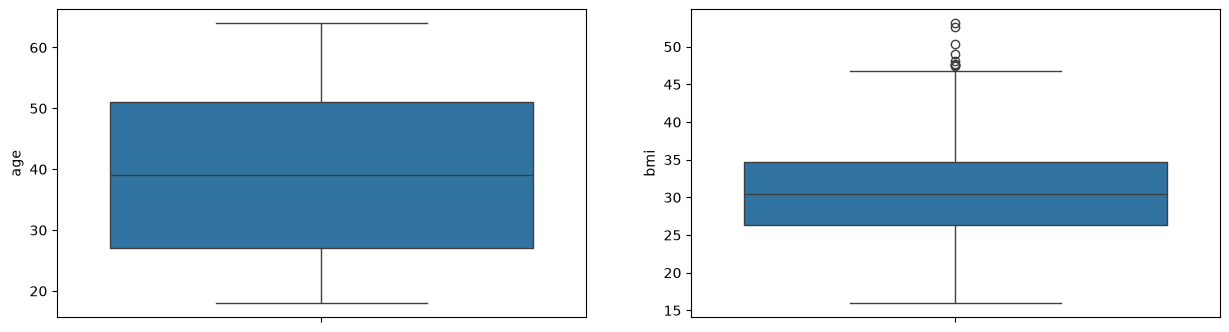

<Axes: xlabel='bmi', ylabel='charges'>

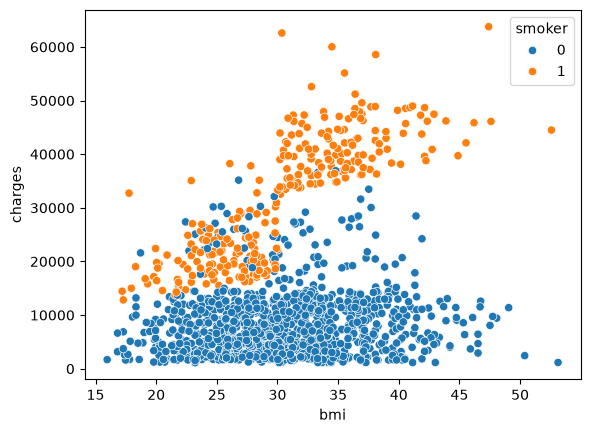

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(y=data['age'], ax=axes[0])
sns.boxplot(y=data['bmi'], ax=axes[1])
plt.show()

sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')

In [5]:
data["sex"] = data["sex"].map({"female": 0, "male": 1})
data["smoker"] = data["smoker"].map({"no": 0, "yes": 1})

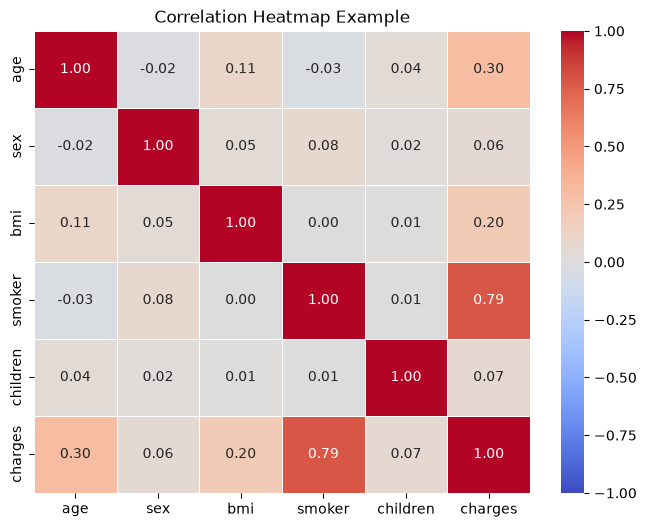

In [10]:
selected_columns = ["age", "sex", "bmi", "smoker", "children", "charges"]
corr_matrix = data[selected_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  
    cmap="coolwarm", 
    fmt=".2f",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
)

plt.title("Correlation Heatmap Example")
plt.show()

In [17]:
numeric_feature = ["age", "bmi", "smoker"]
categorical_features = ["region"]

X = data[["age", "bmi", "smoker", "region"]] 
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_feature),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
alphas = [0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=3)
ridge_cv.fit(X_train_processed, y_train)

model = Ridge(alpha=ridge_cv.alpha_)
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)
print(f"R² score на тесте: {r2_score(y_test, y_pred):.2f}")
print(f"Коэффициенты модели (веса): {model.coef_}")
print(f"Лучший alpha: {ridge_cv.alpha_}")
print(f"Intercept: {model.intercept_}")
print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5}")

R² score на тесте: 0.78
Коэффициенты модели (веса): [3610.85744681 2013.86099023 9476.60966837  434.34996997  106.15592284
 -196.88718945 -343.61870336]
Лучший alpha: 10.0
Intercept: 13349.16174951631
RMSE: 5850.32508237839


In [25]:
'''

R² score на тесте: 0.78
Коэффициенты модели (веса): [3612.43637177 1957.6848604  9477.73872845]
Лучший alpha: 10.0
Intercept: 13346.089736364485
RMSE: 5879.897347491103

R² score на тесте: 0.78
Коэффициенты модели (веса): [3610.85744681 2013.86099023 9476.60966837  434.34996997  106.15592284
 -196.88718945 -343.61870336]
Лучший alpha: 10.0
Intercept: 13349.16174951631
RMSE: 5850.32508237839
'''

'\nR² score на тесте: 0.78\nКоэффициенты модели (веса): [3612.43637177 1957.6848604  9477.73872845]\nЛучший alpha: 10.0\nIntercept: 13346.089736364485\nRMSE: 5879.897347491103\n\nR² score на тесте: 0.78\nКоэффициенты модели (веса): [3610.85744681 2013.86099023 9476.60966837  434.34996997  106.15592284\n -196.88718945 -343.61870336]\nЛучший alpha: 10.0\nIntercept: 13349.16174951631\nRMSE: 5850.32508237839\n'